# import All library 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# import database / Data

In [2]:
conn = sqlite3.connect('customer_churn.db')

#sql query
sql_query = '''
            select name
            from sqlite_master
            where type = 'table'
'''

tables = pd.read_sql(sql_query, conn)

# Create Dataframe for each table

In [3]:
for table_name in tables['name']:
    df = pd.read_sql(f"select * from {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created Dataframe: df_{table_name}")

conn.close()

Created Dataframe: df_db_customer
Created Dataframe: df_db_subscription
Created Dataframe: df_db_support


 # print the column name of each table 

In [4]:
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")

    #get column name information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("columns:")
    print(columns['name'].tolist())

# close connection
conn.close()


Table Name: db_customer
columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# Data Cleaning

In [5]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [6]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [7]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


* a. rename col- name

In [8]:
#df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)
df_db_customer

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


* b. drop column - interest and pincode

In [9]:
df_db_customer.drop(columns = ['interests', 'pincode'], inplace = True)

In [10]:
df_db_customer

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [11]:
# by the use of index we also drop column

# by the help of negative index
df_db_customer.drop(df_db_customer.columns[-2:], axis = 1) 

,customerid,name,country,state
0,0002-ORFBO,keshav,India,Maharashtra
1,0003-MKNFE,raghav,India,Karnataka
2,0004-TLHLJ,lalita,India,Delhi
3,0011-IGKFF,mohan,India,Nagaland
4,0013-EXCHZ,mira,India,Delhi
5,0013-MHZWF,durga,None,Delhi
6,0013-SMEOE,mina,India,Meghalaya
7,0014-BMAQU,madan,India,Rajasthan
8,0015-UOCOJ,maya,None,Kathmandu
9,0016-QLJIS,arjun,Nepal,Kathmandu


In [12]:
# by the use of positive index
df_db_customer.drop(df_db_customer.columns[6:], axis = 1)

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


* c. change data type -DOB

In [13]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [14]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [15]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   customerid  21 non-null     object        
 1   name        21 non-null     object        
 2   country     18 non-null     object        
 3   state       21 non-null     object        
 4   gender      21 non-null     object        
 5   dob         21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


* d. data standarization - gender

In [16]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [17]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women': 'Female'})

In [18]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

* e. fix missing value

In [19]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [20]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [21]:
df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()


{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [22]:
state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()

In [23]:
df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: object

In [24]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [25]:
df_db_customer

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [26]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [27]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,None,None,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,None,None,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,None,None,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,None,None,13.99,790,47


In [28]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [29]:
data_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[data_col] = df_db_subscription[data_col].apply(pd.to_datetime)

In [30]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [31]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [32]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [33]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [34]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [35]:
df_db_support.drop(columns = ['col_1'], inplace = True)

In [36]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
 4   comment         4 non-null      object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 492.0+ bytes


In [37]:
df_db_support.drop(columns = ['comment'], inplace = True)

In [38]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


# Feature Engineering and Data Analysis

In [39]:
df_db_subscription['churn flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [40]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [41]:
df = (df_db_subscription
                .merge(df_db_customer, on = 'customerid', how = 'left')
                .merge(df_db_support, on = 'customerid', how = 'left'))

In [42]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn flag,name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [43]:
df.shape

(23, 20)

In [44]:
df_db_subscription.shape

(21, 12)

In [45]:
df_db_subscription['customerid'].nunique()

21

In [46]:
df_db_subscription['customerid'].size

21

In [47]:
df_db_customer['customerid'].nunique()

21

In [48]:
df_db_customer['customerid'].size

21

In [49]:
df_db_support['customerid'].nunique()

7

In [50]:
df_db_support['customerid'].size

9

In [51]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [52]:
df_db_support.groupby('customerid')['customerid'].transform('count')

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: customerid, dtype: int64

In [53]:
df_db_support['count complain'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [54]:
df_db_support

,customerid,complaint_date,escalations,csat_score,count complain
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [55]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [56]:
df_db_support['customerid'].size

7

In [57]:
# again merge right tables after cleaning 
df = (df_db_subscription
                .merge(df_db_customer, on = 'customerid', how = 'left')
                .merge(df_db_support, on = 'customerid', how = 'left'))

In [58]:
df.shape

(21, 21)

In [59]:
df.to_csv('exported_churn_data.csv', index = False)

# Data Analysis

# 1. Churn Rate

In [60]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'count complain'],
      dtype='object')

In [61]:
churn_rate = df['churn flag'].mean()*100
print(f"Churn Rate {round(churn_rate, 2)} %" )

Churn Rate 28.57 %


# 2. Retension Rate

In [62]:
retention_rate = 100 - churn_rate
print(f"Retention rate {round(retention_rate, 2)} %")

Retention rate 71.43 %


# 3. Churn by Plan type

In [63]:
churn_by_plan = (df.groupby(['plan_type'])['churn flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


# 4 (a). churn by state + sum(revenue) + count of users

In [64]:
churn_by_state = df.groupby(['state'])['churn flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct')

print(churn_by_state)


           state  churn_rate_pct
0          Delhi           25.00
1      Karnataka          100.00
2      Kathmandu            0.00
3    Maharashtra            0.00
4      Meghalaya           66.67
5       Nagaland            0.00
6      Rajasthan            0.00
7      Telangana           50.00
8  Uttar Pradesh            0.00


In [65]:
count_of_users = df.groupby(['state'])['churn flag'].agg(
    user_count=lambda x: (x == 1).sum()
).reset_index()

print(count_of_users)

           state  user_count
0          Delhi           1
1      Karnataka           2
2      Kathmandu           0
3    Maharashtra           0
4      Meghalaya           2
5       Nagaland           0
6      Rajasthan           0
7      Telangana           1
8  Uttar Pradesh           0


In [66]:
churned_df = df[df['churn flag'] == 1]

revenue_loss_by_state = churned_df.groupby('state').agg(
    churned_users=('customerid', 'count'),
    revenue_loss=('monthly_charges', 'sum')
).reset_index()

print(revenue_loss_by_state)

       state  churned_users  revenue_loss
0      Delhi              1         13.99
1  Karnataka              2         20.98
2  Meghalaya              2         21.98
3  Telangana              1         16.99


# 4(b). churn by subscription_type + sum(revenue) + count of users

In [67]:
churn_by_subscription_type = df.groupby(['subscription_type'])['churn flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct')

print(churn_by_subscription_type)

  subscription_type  churn_rate_pct
0           Organic            0.00
1              Paid           16.67
2          Refferal           83.33


In [68]:
count_of_users = df.groupby(['subscription_type'])['churn flag'].agg(
    user_count=lambda x: (x == 1).sum()
).reset_index()

print(count_of_users)

  subscription_type  user_count
0           Organic           0
1              Paid           1
2          Refferal           5


In [69]:
churned_df = df[df['churn flag'] == 1]

revenue_loss_by_subscription_type = churned_df.groupby('subscription_type').agg(
    churned_users=('customerid', 'count'),
    revenue_loss=('monthly_charges', 'sum')
).reset_index()

print(revenue_loss_by_subscription_type)

  subscription_type  churned_users  revenue_loss
0              Paid              1         12.99
1          Refferal              5         60.95


# 5. ARPU - Avg Revenue per Users

In [70]:
arpu = df['monthly_charges'].mean()

print("Avg Revenue per user: ", round(arpu, 2))

Avg Revenue per user:  18.85


# To find the current date and time 

In [71]:
pd.Timestamp.today()

Timestamp('2026-09-24 11:44:18.427211')

# 5. Find age of each user

In [72]:
Today = pd.Timestamp.today()

User_age = (Today - df['dob']).dt.days // 365

print(User_age)

0     44
1     30
2     48
3     25
4     36
5     37
6     50
7     27
8     41
9     32
10    29
11    45
12    21
13    34
14    46
15    40
16    32
17    26
18    42
19    35
20    49
Name: dob, dtype: int64


# 6. Avg Customer Tenure

In [73]:
# count 0f days user has used our services: cancellation date else current date
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
        
    (Today - df['subscription_start_date']).dt.days
)

df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,name,country,state,gender,dob,complaint_date,escalations,csat_score,count complain,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,2019.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1404.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2694.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


In [74]:
# Avg tenure 

Avg_tenure = df['tenure_days'].mean()

print("Avg Tenure (Days): ", round(Avg_tenure, 0))

Avg Tenure (Days):  1546.0


# 7. Revenue at risk- Revenue loss by churned user

In [75]:
revenue_at_risk = df.loc[df['churn flag'] == 1, 'monthly_charges'].sum()

print("Revenue loss due to Churned users(Rs Lakh): ", revenue_at_risk)

Revenue loss due to Churned users(Rs Lakh):  73.94


# 8. Escalation Rate

In [76]:
escalations_rate = (df['escalations'] == 'Y').mean()

print(f"Escalation Rate:  {round(escalations_rate* 100, 2)} %")

Escalation Rate:  19.05 %


# 9. Avg complains per users 

In [77]:
avg_complains = df['count complain'].sum() / df['customerid'].nunique()

print("Avg Complains Per Users: ", round(avg_complains, 2))

Avg Complains Per Users:  0.43


# 10. Correlation Escalation vs churn 

In [78]:
df[['customerid', 'escalations', 'churn flag']].dropna()

,customerid,escalations,churn flag
1,0003-MKNFE,Y,1
4,0013-EXCHZ,Y,1
5,0013-MHZWF,N,0
6,0013-SMEOE,N,1
11,0017-IUDMW,Y,1
13,0019-EFAEP,Y,1
18,0022-TCJCI,N,1


In [79]:
# encoding escalation from string to int type

df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)

df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,name,country,state,gender,dob,complaint_date,escalations,csat_score,count complain,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2019.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1404.0


In [80]:
corr_df = df[['customerid', 'escalations', 'churn flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn flag'])

print("Correlation Between escalation and churn flag: ", round(correlation, 2))

Correlation Between escalation and churn flag:  0.77


# 11. Create a column using exsiting column -- Churn risk

In [81]:
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 50),
]

risk_condition = ['Low', 'Med', 'High']

df['churn_risk'] = np.select(conditions, risk_condition, default = 'unkown')

In [82]:
df[['churn_score', 'churn_risk']]

,churn_score,churn_risk
0,12,Low
1,91,High
2,34,Low
3,8,Low
4,88,High
5,22,Low
6,79,High
7,5,Low
8,34,Low
9,41,Low


In [83]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'count complain',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [84]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,count complain,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2019.0,Low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,High
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1404.0,Low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2694.0,Low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,High


# Vsualization using matplotlib

In [85]:
df_visual = df.copy()

In [86]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'count complain',
       'tenure_days', 'churn_risk'],
      dtype='object')

# 1. Monthly Churn Trend (Time series KPI)

In [87]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn flag'] == 1].groupby('cancellation_month').size()

print(churn_trend)

cancellation_month
2024-02    1
2024-05    1
2024-09    2
2024-10    1
2024-11    1
Freq: M, dtype: int64


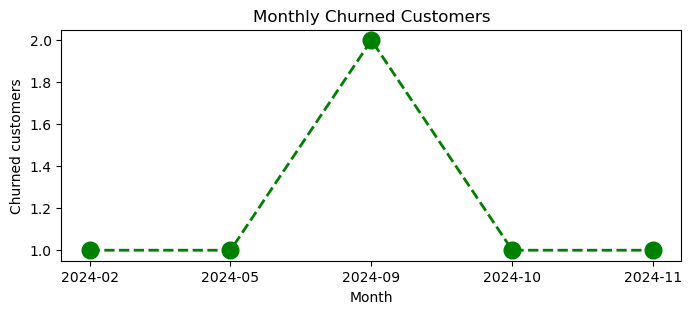

In [88]:
plt.figure(figsize=(8, 3))

plt.plot(churn_trend.index.astype(str), churn_trend.values, color = 'green', marker = 'o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly Churned Customers')
plt.xlabel('Month')
plt.ylabel('Churned customers')
plt.show()

# 2. Churn By plan Type 

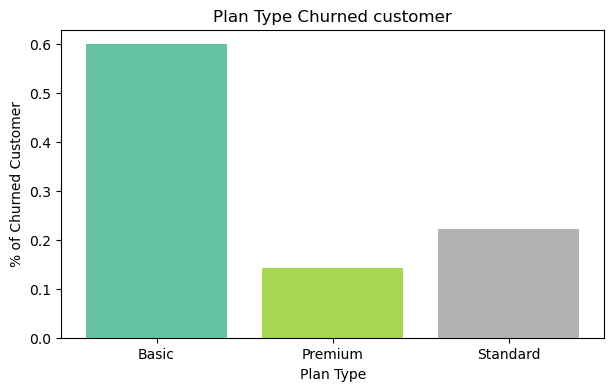

In [89]:
churn_by_plan_type = df_visual.groupby('plan_type')['churn flag'].mean()

#colors = ['Blue', 'green', 'yellow']

# for all bars when some new bars are add in chart
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_by_plan_type)))

plt.figure(figsize = (7, 4))
plt.bar(churn_by_plan_type.index, churn_by_plan_type.values, color = colors)
plt.title('Plan Type Churned customer')
plt.xlabel('Plan Type')
plt.ylabel('% of Churned Customer')

plt.show()

# 3. Churn by State 

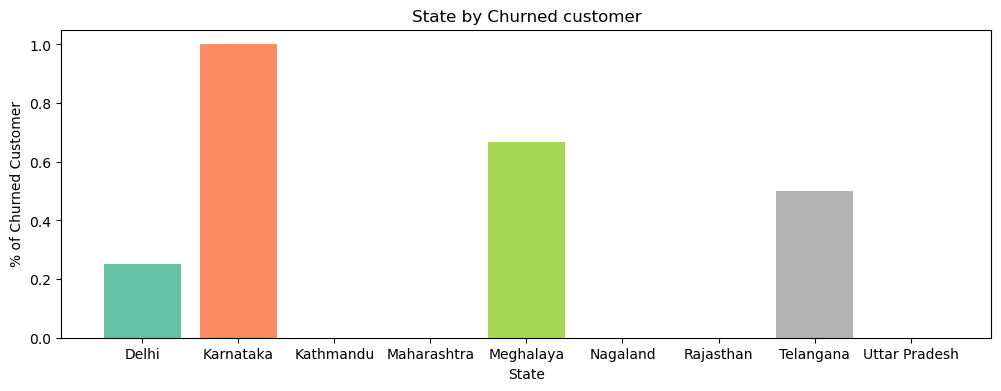

In [92]:
churn_by_plan_type = df_visual.groupby('state')['churn flag'].mean()

#colors = ['Blue', 'green', 'yellow']

# for all bars when some new bars are add in chart
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_by_plan_type)))

plt.figure(figsize = (12, 4))
plt.bar(churn_by_plan_type.index, churn_by_plan_type.values, color = colors)
plt.title('State by Churned customer')
plt.xlabel('State')
plt.ylabel('% of Churned Customer')

plt.show()

# 4. Churned By Gender

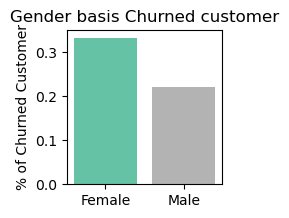

In [100]:
churn_by_plan_type = df_visual.groupby('gender')['churn flag'].mean()

#colors = ['Blue', 'green', 'yellow']

# for all bars when some new bars are add in chart
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_by_plan_type)))

plt.figure(figsize = (2, 2))
plt.bar(churn_by_plan_type.index, churn_by_plan_type.values, color = colors)
plt.title('Gender basis Churned customer')

plt.ylabel('% of Churned Customer')

plt.show()

# 5. Churn by Subcription Type

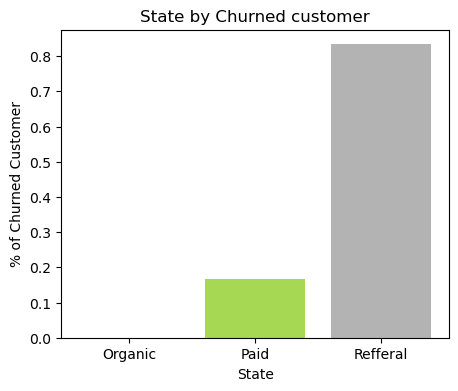

In [105]:
churn_by_plan_type = df_visual.groupby('subscription_type')['churn flag'].mean()

#colors = ['Blue', 'green', 'yellow']

# for all bars when some new bars are add in chart
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_by_plan_type)))

plt.figure(figsize = (5, 4))
plt.bar(churn_by_plan_type.index, churn_by_plan_type.values, color = colors)
plt.title('State by Churned customer')
plt.xlabel('State')
plt.ylabel('% of Churned Customer')

plt.show()

# Visualization using seaborn 

# Heatmap (Correlation Matrix)

In [109]:
# Encoding - convert str to numeric so that we can find the correlation between features

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn flag', 'churn_risk', 'escalations']].head()

In [107]:
df_encoded

,plan_type,contract_type,churn_score,churn flag,churn_risk,escalations
0,Standard,Annual,12,0,Low,0
1,Premium,Annual,91,1,High,1
2,Basic,Monthly,34,0,Low,0
3,Premium,Annual,8,0,Low,0
4,Standard,Monthly,88,1,High,1


In [111]:
# Incorrect method of Incoding - an numbers are not assigned based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn flag', 'churn_risk', 'escalations']].head()

categoricals_col = ['plan_type', 'contract_type', 'churn_risk']

for col in categoricals_col:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes 

In [112]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

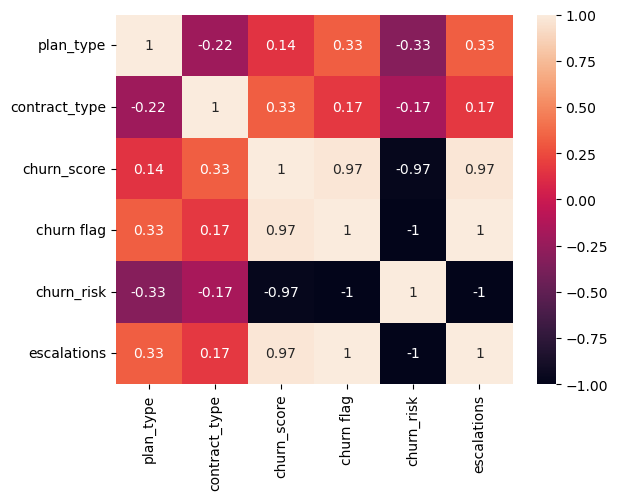

In [113]:
# Heatmap 

sns.heatmap(df_encoded.corr(), annot = True)

In [121]:
# Correct method of Incoding - based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn flag', 'churn_risk', 'escalations']]

order_mappings = {'plan_type' : ['Basic', 'Standard', 'Premium'], 
                    'contract_type' : ['Monthly', 'Annual'], 
                    'churn_risk' : ['Low', 'Med', 'High']}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered = True).codes

C:\Users\Asus\AppData\Local\Temp\ipykernel_23140\3204934683.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered = True).codes
C:\Users\Asus\AppData\Local\Temp\ipykernel_23140\3204934683.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered = True).codes
C:\Users\Asus\AppData\Local\Temp\ipykernel_23140\3204934683.py:1

In [120]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [122]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn flag,churn_risk,escalations
0,Standard,Annual,12,0,Low,0
1,Premium,Annual,91,1,High,1
2,Basic,Monthly,34,0,Low,0
3,Premium,Annual,8,0,Low,0
4,Standard,Monthly,88,1,High,1


In [117]:
df_visual['churn_risk'].unique()

array(['Low', 'High', 'Med'], dtype=object)

<Axes: >

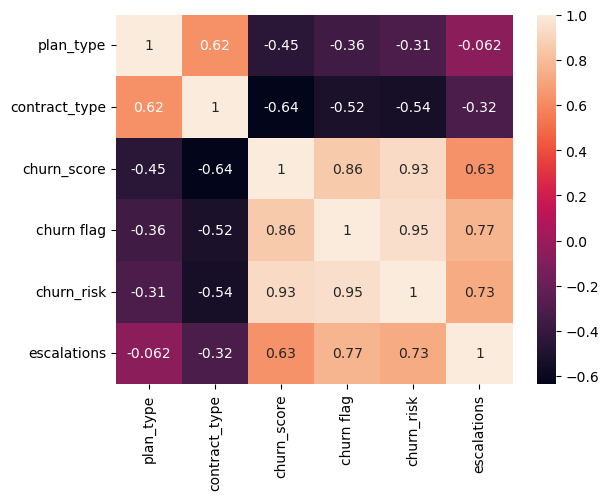

In [123]:
# Heatmap correct 

sns.heatmap(df_encoded.corr(), annot = True)

# Pairplot - relationship in a dataset 

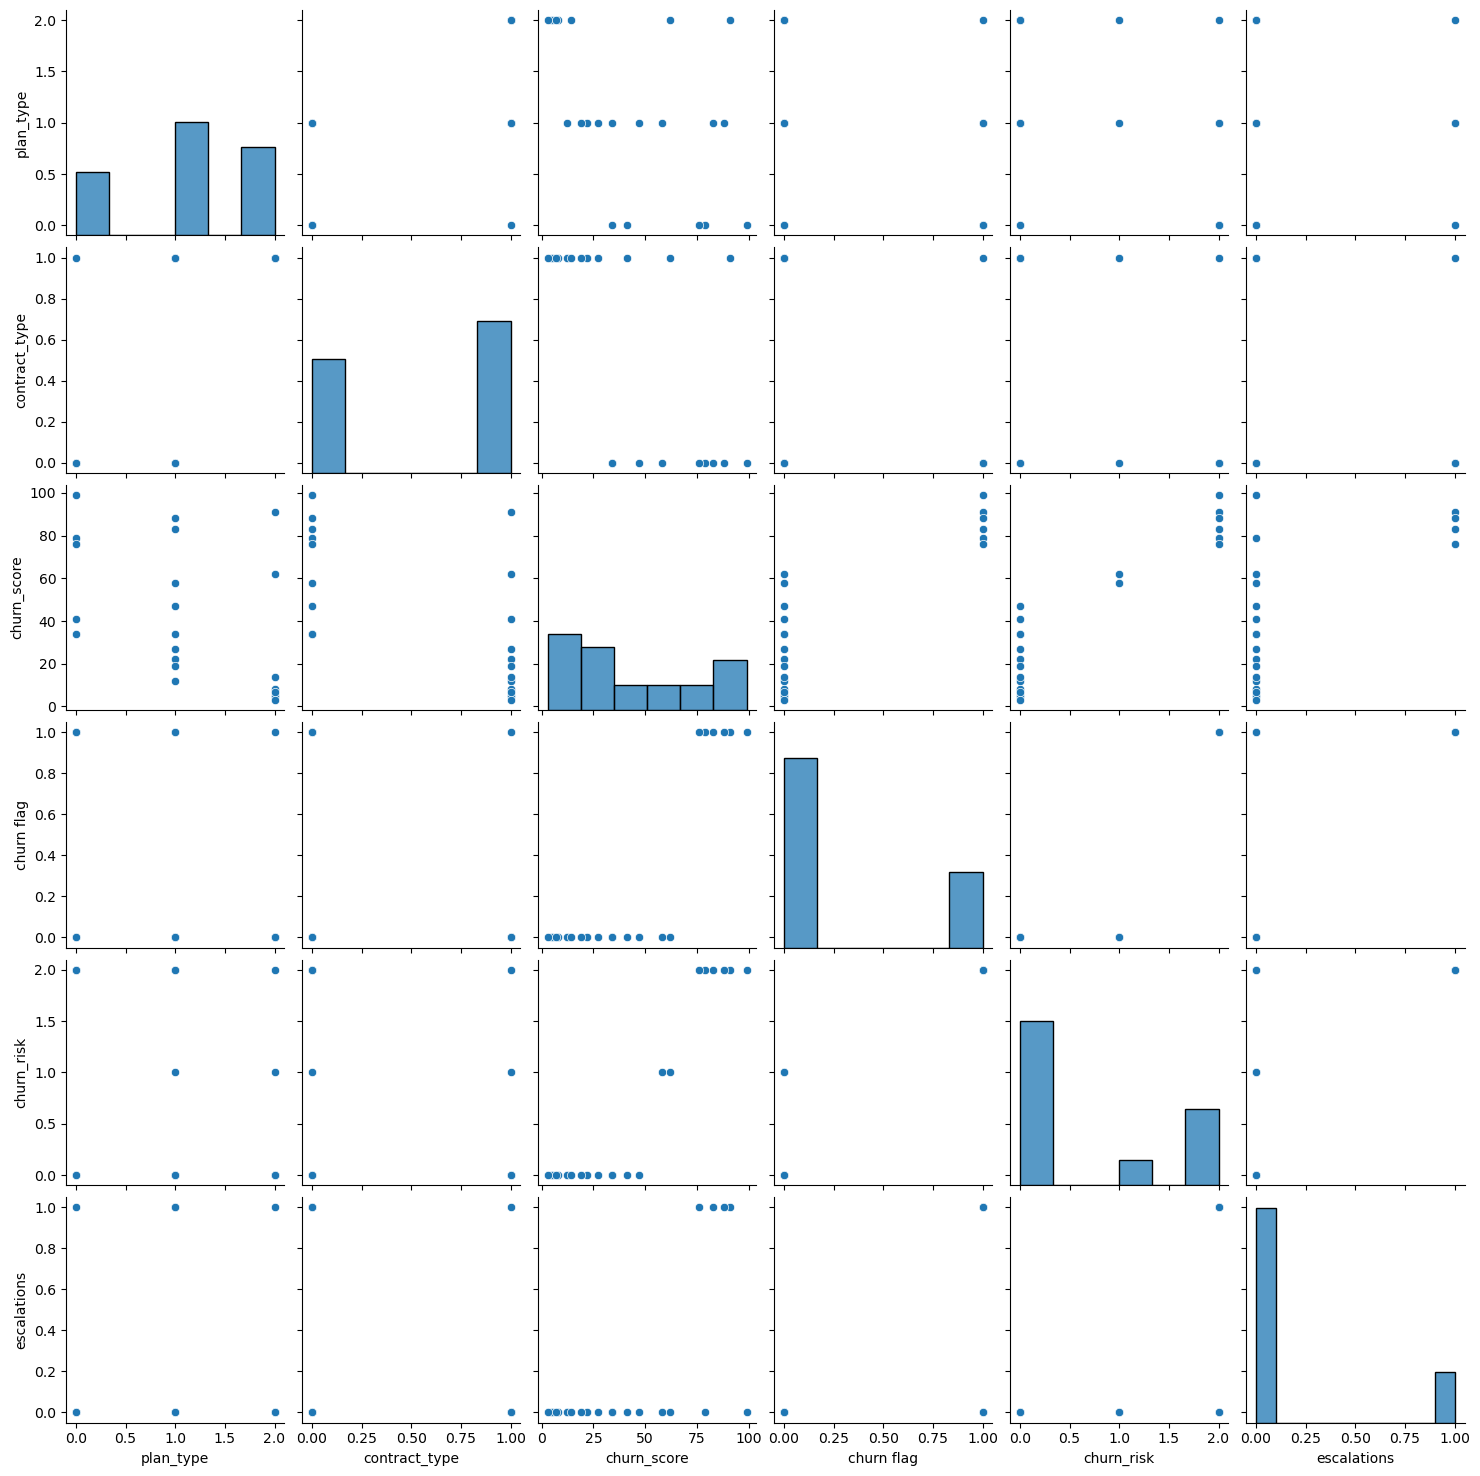

In [124]:
sns.pairplot(df_encoded)

# Catplt / facegrid plot - multi- dimension comparison

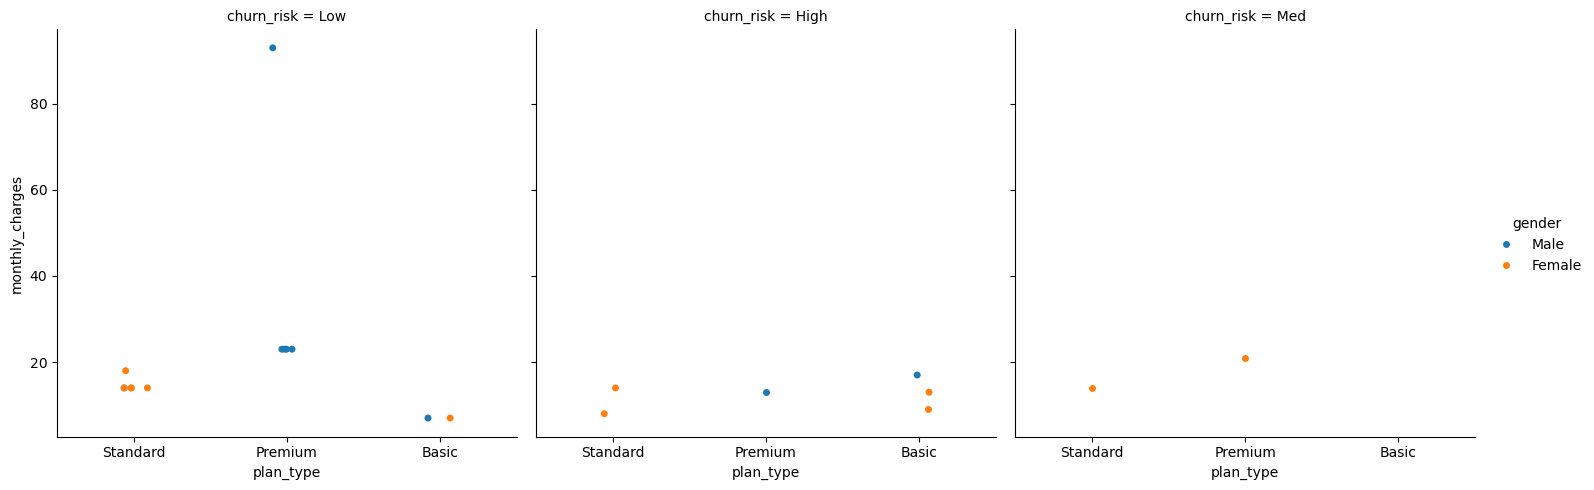

In [125]:
# chart 
sns.catplot(data = df_visual,
           x = 'plan_type',
           y = 'monthly_charges',
           hue = 'gender',
           col = 'churn_risk')

# Pivot Table

In [127]:
pd.pivot_table(
    data = df_visual,
    index = 'plan_type',
    values = 'churn flag',
    aggfunc = 'mean'
)

,churn flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [128]:
pd.pivot_table(
    data = df_visual,
    index = 'plan_type',
    values = ['monthly_charges', 'customerid', 'churn flag'],
    aggfunc = {'monthly_charges' : 'sum', 
               'customerid' : 'nunique', 
               'churn flag' : 'mean'}
)

,churn flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [96]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'count complain',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [94]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,count complain,tenure_days,churn_risk,cancellation_month
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2019.0,Low,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,High,2024-09
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1404.0,Low,NaT
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2694.0,Low,NaT
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,High,2024-02
